# Using Scaling and encoding technique on insurance.csv (multiple features numeric and categorical) Medical cost personal dataset 

## Loading Dataset

In [157]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [158]:
df = pd.read_csv("../datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Preparation

In [159]:
x = df.drop(columns = 'charges')
y = df['charges']

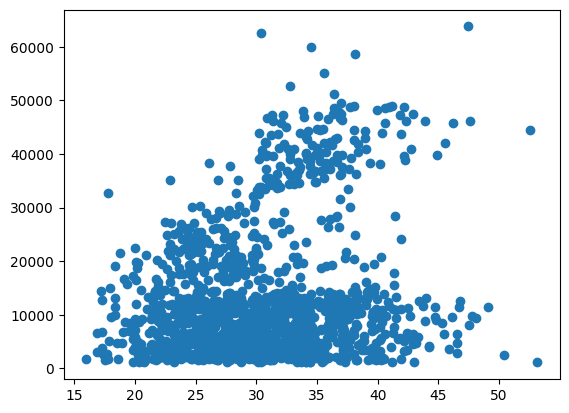

In [160]:
plt.scatter(x['bmi'],y)

In [161]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [162]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

print(obj_cols) # this contains only categorical data
print(num_cols) # this contains only numerical data

Index(['sex', 'smoker', 'region'], dtype='str')
Index(['age', 'bmi', 'children'], dtype='str')


C:\Users\shankar paikira\AppData\Local\Temp\ipykernel_22836\1426429871.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = x.select_dtypes(include='object').columns


### Checking the for outliers

<Axes: >

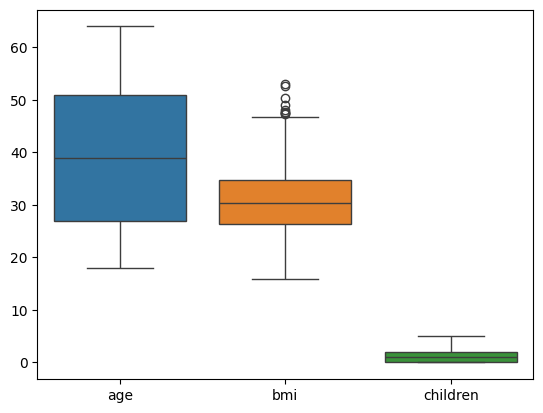

In [163]:
sns.boxplot(x[num_cols])
# since there are less outliers we will use Standard Scaler

### Splitting data into train and test data separately

In [164]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [165]:
xtrain

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


### Then using the scaling technique

--- 
we can use **" StandardScaler "** since we have few outliers, if we had no outliers then we could use normalization (MinMax Scaler) 

In [166]:
# scaling = MinMaxScaler()
# xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
# xtrain

In [167]:
scaling = StandardScaler()
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
xtrain  # changed the original xtrain data itself didnt store in separate variable 

,age,sex,bmi,children,smoker,region
560,0.472227,female,-1.756525,0.734336,no,northwest
1285,0.543313,female,-1.033082,-0.911192,no,northeast
1142,0.898745,female,-0.943687,-0.911192,no,southeast
969,-0.025379,female,0.622393,3.202629,no,southeast
486,1.040918,female,-1.504893,1.557100,no,northwest
...,...,...,...,...,...,...
1095,-1.518194,female,0.130717,2.379865,no,northeast
1130,-0.025379,female,-1.107579,3.202629,no,southeast
1294,1.325264,male,-0.891539,-0.911192,no,northeast
860,-0.167551,female,2.820864,0.734336,yes,southwest


In [168]:
df.select_dtypes(include='number').corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


### Then using Encoding technique - beacuse it is applied on obj cols only 

In [169]:
xtrain[obj_cols].nunique()

sex       2
smoker    2
region    4
dtype: int64

In [170]:
# label_encoder = LabelEncoder()  

# '''  takes only 1d 
# xtrain[obj_cols] = label_encoder.fit_transform(xtrain[obj_cols])
# ValueError: y should be a 1d array, got an array of shape (1070, 3) instead.
# '''


# '''
# xtrain['sex'] = label_encoder.fit_transform(xtrain[['sex','smoker']])
# # ValueError: y should be a 1d array, got an array of shape (1070, 3) instead.
# '''

# THIS WILL WORK: 
# xtrain['sex'] = label_encoder.fit_transform(xtrain['sex']) 
# this will work but only for 1 column , for multiple columns we will use "onehot encoder"

In [171]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values = onehot_encoder.fit_transform(xtrain[obj_cols])
cols = onehot_encoder.get_feature_names_out()

cols  # created new features

array(['sex_female', 'sex_male', 'smoker_no', 'smoker_yes',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'], dtype=object)

In [172]:
xtrain[cols] = values
xtrain.drop(columns = ['sex', 'smoker', 'region'],inplace= True)
xtrain

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1285,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1142,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
969,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
486,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1130,-0.025379,-1.107579,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1294,1.325264,-0.891539,-0.911192,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
860,-0.167551,2.820864,0.734336,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [173]:
xtest[num_cols] = scaling.transform(xtest[num_cols])
xtest_values = onehot_encoder.transform(xtest[obj_cols])
xtest[cols] = xtest_values
xtest.drop(columns=['sex', 'smoker', 'region'], inplace=True)


# we can dd this polynomial ferature later if we want to improvew the score of the model 

# # Polynomial feature expansion for numeric columns
# poly = PolynomialFeatures(degree=2, include_bias=False)

# xtrain_poly = pd.DataFrame(
#     poly.fit_transform(xtrain[num_cols]),
#     columns=poly.get_feature_names_out(num_cols),
#     index=xtrain.index
# )

# xtest_poly = pd.DataFrame(
#     poly.transform(xtest[num_cols]),
#     columns=poly.get_feature_names_out(num_cols),
#     index=xtest.index
# )

# xtrain = pd.concat([xtrain_poly, xtrain[cols]], axis=1)
# xtest = pd.concat([xtest_poly, xtest[cols]], axis=1)

xtrain


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1285,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1142,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
969,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
486,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1130,-0.025379,-1.107579,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1294,1.325264,-0.891539,-0.911192,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
860,-0.167551,2.820864,0.734336,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [174]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Evaluation

In [175]:
model.score(xtrain,ytrain)

0.7417255854683333

In [176]:
model.score(xtest,ytest)

0.7835929767120722

In [177]:
y_pred_train = model.predict(xtrain)
y_pred_test = model.predict(xtest)

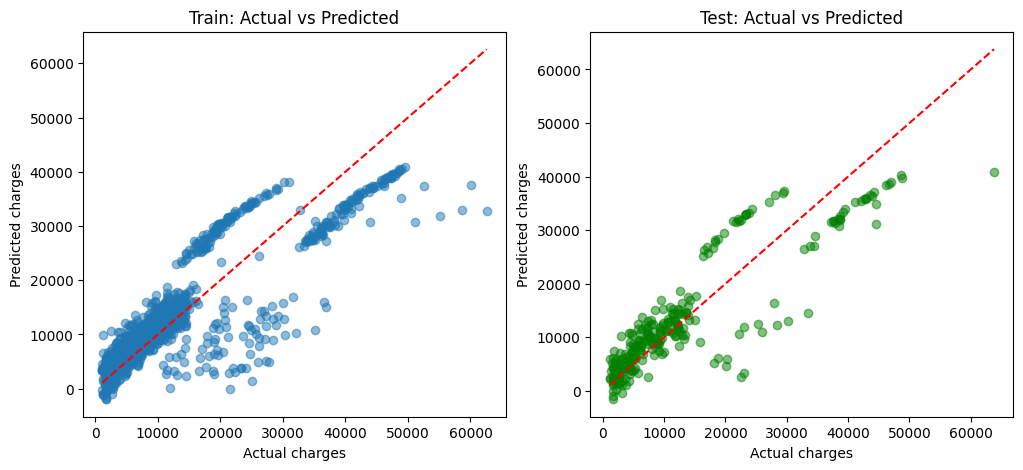

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(ytrain, y_pred_train, alpha=0.5)
plt.plot([ytrain.min(), ytrain.max()], [ytrain.min(), ytrain.max()], color='red', linestyle='--')
plt.title("Train: Actual vs Predicted")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")

plt.subplot(1, 2, 2)
plt.scatter(ytest, y_pred_test, alpha=0.5, color='green')
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], color='red', linestyle='--')
plt.title("Test: Actual vs Predicted")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")

# plt.tight_layout()
plt.show()

### Plotting individual feature vs target

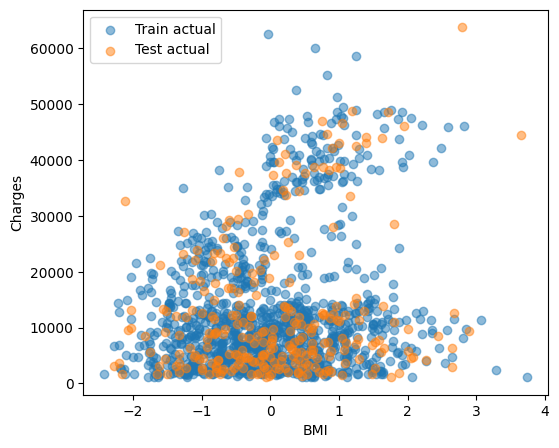

In [179]:
plt.figure(figsize=(6, 5))
plt.scatter(xtrain['bmi'], ytrain, alpha=0.5, label='Train actual')
plt.scatter(xtest['bmi'], ytest, alpha=0.5, label='Test actual')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.legend()
plt.show()

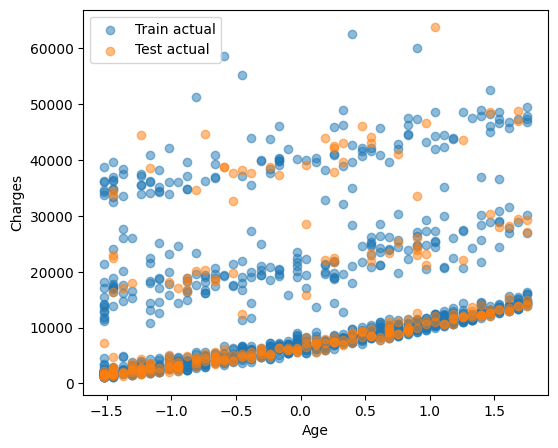

In [180]:
plt.figure(figsize=(6, 5))
plt.scatter(xtrain['age'], ytrain, alpha=0.5, label='Train actual')
plt.scatter(xtest['age'], ytest, alpha=0.5, label='Test actual')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend()
plt.show()

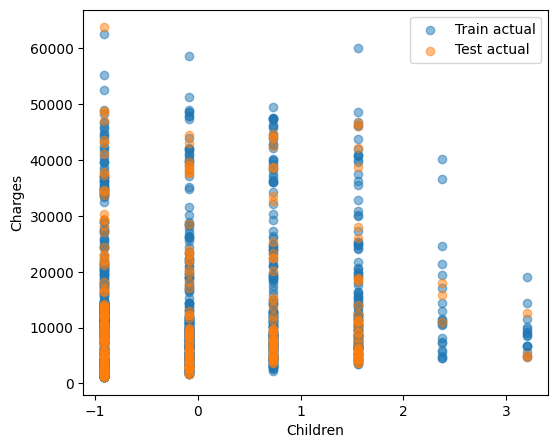

In [181]:
plt.figure(figsize=(6, 5))
plt.scatter(xtrain['children'], ytrain, alpha=0.5, label='Train actual')
plt.scatter(xtest['children'], ytest, alpha=0.5, label='Test actual')
plt.xlabel("Children")
plt.ylabel("Charges")
plt.legend()
plt.show()